## Probing the Spectral Energy Distributions of SALT2 models generated
Note: most of the code here were done with AI assistance.

In [1]:
# import required packages:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import lightcurve
import lsst_functions
from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility

# import cosmology parameters
import sncosmo
from params import p_cosmology

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"] #note: lightcurve.py uses "redshift" 

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
tmin = 61208.203 # in mjd
tmax = 61566.074 # 1 year

In [3]:
# The three lines here are not important, You could simply use .SNeIa.from_draw()to retrive the default model.
# Here, I simply copy-pasted the same lines used to generate general populations, but with N_tot = 1
# snia_dict = generate_snia_dict(redshift = None, ra = None, dec = None, x1 = None, t0 = None, magabs = None, c = None)
snia_dict = generate_snia_dict(redshift = 0.2, ra = 14.9, dec = -22.9, x1 = 0, t0 = None, magabs = -19.323, c = 0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = lsst_bands, in_mag = False, N_tot = 1, tstart = tmin -100, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)

CUSTOM MODEL IS {'redshift': {'func': <function fixed_param at 0x76c3311028d0>, 'kwargs': {'size': 1, 'value': 0.2}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x76c3311028d0>, 'kwargs': {'size': 1, 'value': 0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x76c3311028d0>, 'kwargs': {'size': 1, 'value': 0}, 'as': 'c'}, 'magabs': {'func': <function fixed_param at 0x76c3311028d0>, 'kwargs': {'size': 1, 'value': -19.323}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x76c331102980>, 'kwargs': {'size': 1, 'ra': 14.9, 'dec': -22.9}, 'as': ['ra', 'dec']}}


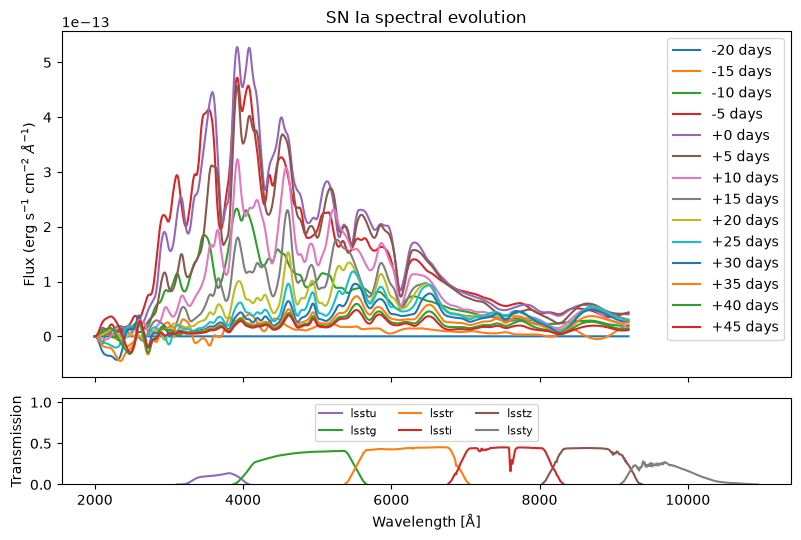

In [4]:
# show lightcurves at different phases for each model
import numpy as np
import matplotlib.pyplot as plt
import sncosmo

model = snia_models.template.sncosmo_model

phases = np.arange(-20,50,5)

wavelength = np.linspace(model.minwave(),model.maxwave(),2000)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 5.5),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

# SN Ia spectrum
for phase in phases:

    flux = model.flux(phase, wavelength)
    ax1.plot(wavelength,flux,label=f"{phase:+d} days")

ax1.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")

ax1.set_title("SN Ia spectral evolution")
ax1.legend()

# LSST transmission curves
for band, color in zip(lsst_bands, lsst_colors):

    bandpass = sncosmo.get_bandpass(band)

    wave = np.linspace(
        bandpass.minwave(),
        bandpass.maxwave(),
        500
    )

    transmission = bandpass(wave)

    ax2.plot(
        wave,
        transmission,
        color=color,
        label=band
    )

ax2.set_xlabel("Wavelength [Å]")
ax2.set_ylabel("Transmission")
ax2.set_ylim(0, 1.05)

ax2.legend(
    ncol=3,
    fontsize=8,
    loc="upper center"
)

plt.tight_layout()
plt.show()

In [5]:
print(snia_models.template.sncosmo_model.parameters)
print(snia_models.template.sncosmo_model.param_names)

[0. 0. 1. 0. 0.]
['z', 't0', 'x0', 'x1', 'c']


#### Create a gif of SNIa SED plot

In [ ]:
# create a gif

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from pathlib import Path

model = snia_models.template.sncosmo_model

phases = np.arange(-20, 55, 5)

wavelength = np.linspace(
    model.minwave(),
    model.maxwave(),
    2000
)

lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]

lsst_colors = [
    "tab:purple",
    "tab:green",
    "tab:orange",
    "tab:red",
    "tab:brown",
    "0.5",
]

# Directory for GIF frames
output_dir = Path("spectrum_frames")
output_dir.mkdir(exist_ok=True)


for phase in phases:

    # ========================================================
    # Create figure
    # ========================================================

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(7, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1]}
    )

    # ========================================================
    # Top: SN Ia spectrum at ONE phase
    # ========================================================

    flux = model.flux(
        phase,
        wavelength
    )

    ax1.plot(
        wavelength,
        flux
    )

    ax1.set_ylim(-0.2e-13, 5.4e-13)

    ax1.set_ylabel(
        r"Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)"
    )

    ax1.set_title(
        f"SN Ia spectrum — phase = {phase:+d} days"
    )

    # ========================================================
    # Bottom: LSST transmission curves
    # ========================================================

    for band, color in zip(lsst_bands, lsst_colors):

        bandpass = sncosmo.get_bandpass(band)

        wave = np.linspace(
            bandpass.minwave(),
            bandpass.maxwave(),
            500
        )

        transmission = bandpass(wave)

        ax2.plot(
            wave,
            transmission,
            color=color,
            label=band
        )

    ax2.set_xlabel("Wavelength [Å]")
    ax2.set_ylabel("Transmission")
    ax2.set_ylim(0, 1.05)

    ax2.legend(
        ncol=6,
        fontsize=8,
        loc="upper center"
    )

    # ========================================================
    # Save frame
    # ========================================================

    plt.tight_layout()

    # filename = output_dir / f"spectrum_phase_{phase:+03d}.png"

    # fig.savefig(filename,dpi=150,bbox_inches="tight") #uncomment if you want to save

    plt.close(fig)

    # print(f"Saved: {filename}")

#### Compare SED shape at phase = 0 (i.e. t0 in B band) for different (x1, c)

c = 0, x1 = 0
source:
  class      : SALT2Source
  name       : 'salt2'
  version    : T23
  phases     : [-20, .., 50] days
  wavelengths: [2000, .., 9200] Angstroms
parameters:
  z  = np.float64(0.0)
  t0 = np.float64(0.0)
  x0 = np.float64(1.0)
  x1 = np.float64(0.0)
  c  = np.float64(0.0)
c = 0, x1 = 1.0
source:
  class      : SALT2Source
  name       : 'salt2'
  version    : T23
  phases     : [-20, .., 50] days
  wavelengths: [2000, .., 9200] Angstroms
parameters:
  z  = np.float64(0.0)
  t0 = np.float64(0.0)
  x0 = np.float64(1.0)
  x1 = np.float64(-1.0)
  c  = np.float64(0.0)
c = -0.2, x1 = 0
source:
  class      : SALT2Source
  name       : 'salt2'
  version    : T23
  phases     : [-20, .., 50] days
  wavelengths: [2000, .., 9200] Angstroms
parameters:
  z  = np.float64(0.0)
  t0 = np.float64(0.0)
  x0 = np.float64(1.0)
  x1 = np.float64(0.0)
  c  = np.float64(-0.2)


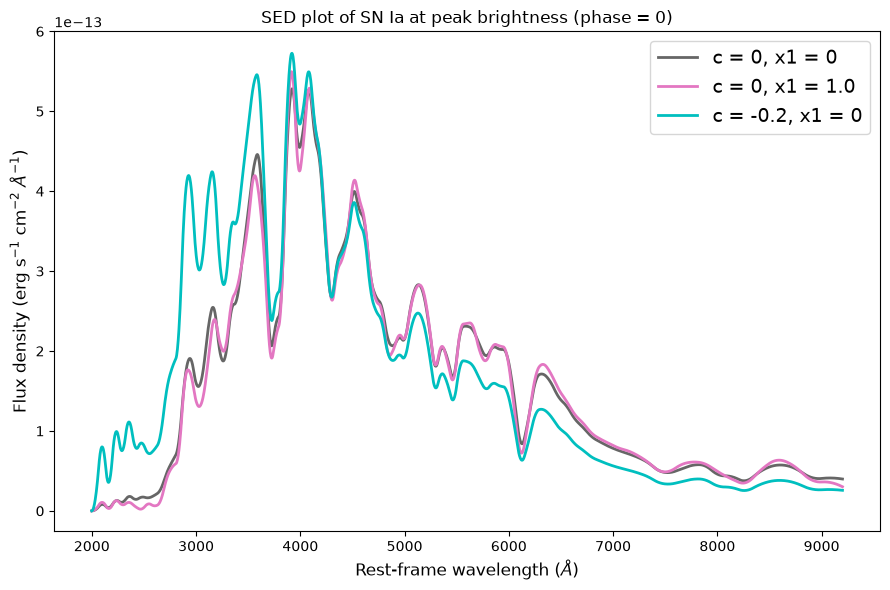

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sncosmo

cases = [
    {"label": "c = 0, x1 = 0",      "c": 0.0,  "x1": 0.0, "color": '0.4'},
    {"label": "c = 0, x1 = 1.0",      "c": 0.0,  "x1": -1.0, "color": 'tab:pink'},
    {"label": "c = -0.2, x1 = 0",   "c": -0.2, "x1": 0.0, "color": 'c'},
    # {"label": "c = -0.2, x1 = 1.0", "c": -0.2, "x1": 1.0, "color": 'b'},
]

fig, ax = plt.subplots(figsize=(9, 6))

wavelength = np.linspace(2000, 9200, 2000)

for case in cases:

    # Create a completely independent SALT2 model
    model = sncosmo.Model(source="salt2")

    # Set the parameters you want
    model.set(
        z=0.0,
        t0=0.0,
        x0=1.0,
        x1=case["x1"],
        c=case["c"],
    )

    print(case["label"])
    print(model)

    # Phase = 0
    flux = model.flux(
        0.0,
        wavelength
    )

    ax.plot(
        wavelength,
        flux,
        linewidth=2,
        label=case["label"],
        color = case["color"]
    )

ax.set_xlabel(r"Rest-frame wavelength ($\AA$)", fontsize = 12)
ax.set_ylabel(
    r"Flux density (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)",
    fontsize = 12
)
ax.set_ylim(-0.25e-13,6e-13)
# ax.set_title("SED plot of SN Ia, different (x1, c) at peak brightness (phase = 0)")
ax.set_title("SED plot of SN Ia at peak brightness (phase = 0)")
ax.legend(fontsize = 14)

plt.tight_layout()
plt.show()

In [7]:
models = [
    {
        "label": "c = 0, x1 = 0",
        "params": {
            "z": np.float64(0.0),
            "t0": np.float64(0.0),
            "x0": np.float64(1.0),
            "x1": np.float64(0.0),
            "c": np.float64(0.0),
        },
    },
    {
        "label": "c = -0.2, x1 = 0",
        "params": {
            "z": np.float64(0.0),
            "t0": np.float64(0.0),
            "x0": np.float64(1.0),
            "x1": np.float64(0.0),
            "c": np.float64(-0.2),
        },
    },
    {
        "label": "c = -0.2, x1 = 0.2",
        "params": {
            "z": np.float64(0.0),
            "t0": np.float64(0.0),
            "x0": np.float64(1.0),
            "x1": np.float64(0.2),
            "c": np.float64(-0.2),
        },
    },
]

models

[{'label': 'c = 0, x1 = 0',
  'params': {'z': np.float64(0.0),
   't0': np.float64(0.0),
   'x0': np.float64(1.0),
   'x1': np.float64(0.0),
   'c': np.float64(0.0)}},
 {'label': 'c = -0.2, x1 = 0',
  'params': {'z': np.float64(0.0),
   't0': np.float64(0.0),
   'x0': np.float64(1.0),
   'x1': np.float64(0.0),
   'c': np.float64(-0.2)}},
 {'label': 'c = -0.2, x1 = 0.2',
  'params': {'z': np.float64(0.0),
   't0': np.float64(0.0),
   'x0': np.float64(1.0),
   'x1': np.float64(0.2),
   'c': np.float64(-0.2)}}]

c = 0, x1 = 0
source:
  class      : SALT2Source
  name       : 'salt2'
  version    : T23
  phases     : [-20, .., 50] days
  wavelengths: [2000, .., 9200] Angstroms
parameters:
  z  = np.float64(0.0)
  t0 = np.float64(0.0)
  x0 = np.float64(1.0)
  x1 = np.float64(0.0)
  c  = np.float64(0.0)
c = -0.2, x1 = 0
source:
  class      : SALT2Source
  name       : 'salt2'
  version    : T23
  phases     : [-20, .., 50] days
  wavelengths: [2000, .., 9200] Angstroms
parameters:
  z  = np.float64(0.0)
  t0 = np.float64(0.0)
  x0 = np.float64(1.0)
  x1 = np.float64(0.0)
  c  = np.float64(-0.2)
c = -0.2, x1 = 0.2
source:
  class      : SALT2Source
  name       : 'salt2'
  version    : T23
  phases     : [-20, .., 50] days
  wavelengths: [2000, .., 9200] Angstroms
parameters:
  z  = np.float64(0.0)
  t0 = np.float64(0.0)
  x0 = np.float64(1.0)
  x1 = np.float64(0.2)
  c  = np.float64(-0.2)


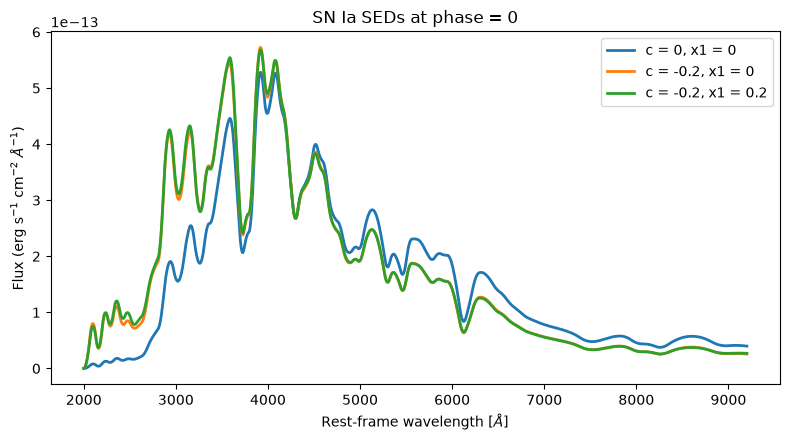

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for item in models:

    params = item["params"]

    # Make a completely new SALT2 model
    model = sncosmo.Model(source="salt2")

    model.set(
        z=params["z"],
        t0=params["t0"],
        x0=params["x0"],
        x1=params["x1"],
        c=params["c"],
    )

    print(item["label"])
    print(model)

    # Observer-frame wavelength
    wavelength_obs = np.linspace(
        model.minwave(),
        model.maxwave(),
        2000
    )

    # Phase = 0
    flux = model.flux(
        model.get("t0"),
        wavelength_obs
    )

    # Convert wavelength to rest frame
    wavelength_rest = wavelength_obs / (1 + model.get("z"))

    ax.plot(
        wavelength_rest,
        flux,
        linewidth=2,
        label=item["label"]
    )

ax.set_xlabel(r"Rest-frame wavelength [$\AA$]")
ax.set_ylabel(
    r"Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)"
)
ax.set_title("SN Ia SEDs at phase = 0")
ax.legend()

plt.tight_layout()
plt.show()